The ``aa.plot_comparison()`` function draws the recurring "benchmark result" figure from a tidy (long-form) evaluation frame: each ``condition`` becomes an x-axis cluster, each ``group`` a colored bar within it (with automatic bar offsets and widths for *N* groups), with per-bar value labels and an optional dashed chance / baseline line. One call replaces the manual ``x ± w/2`` offsets, the per-bar ``ax.text`` loop, and the manual ``axhline`` of a hand-built grouped barplot.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import aaanalysis as aa

aa.options["verbose"] = False

# Tidy eval frame: one row per (group, condition) cell.
df_eval = pd.DataFrame({
    "group":     ["Scale-based"] * 3 + ["CPP"] * 3,
    "condition": ["No expansion", "Random", "dPULearn"] * 2,
    "value":     [61, 60, 75, 71, 74, 94],
})
aa.display_df(df_eval, n_rows=10, show_shape=True)

DataFrame shape: (6, 3)


,group,condition,value
1,Scale-based,No expansion,61
2,Scale-based,Random,60
3,Scale-based,dPULearn,75
4,CPP,No expansion,71
5,CPP,Random,74
6,CPP,dPULearn,94


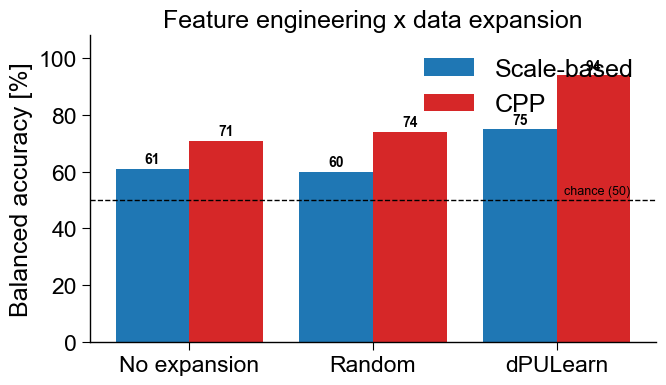

In [2]:
aa.plot_settings()
aa.plot_comparison(df_eval=df_eval, baseline=50,
                   ylabel="Balanced accuracy [%]",
                   title="Feature engineering x data expansion")
plt.tight_layout()
plt.show()

**Further parameters.** ``plot_comparison`` also accepts: ``group`` / ``condition`` / ``value`` — the column names of the tidy frame; ``baseline_label`` — text for the baseline line (auto ``"chance (50)"`` by default, ``""`` to hide); ``annotate`` — toggle the per-bar value labels; ``group_order`` / ``condition_order`` — explicit bar / cluster order; ``colors`` — a list aligned to the groups or a ``group -> color`` dict (defaults to the house palette of ``aa.plot_get_clist``); ``bar_width`` — total cluster width; ``figsize``; ``xlabel``; ``ylim``; ``fontsize_annotations``; and ``ax`` to draw onto an existing axes.

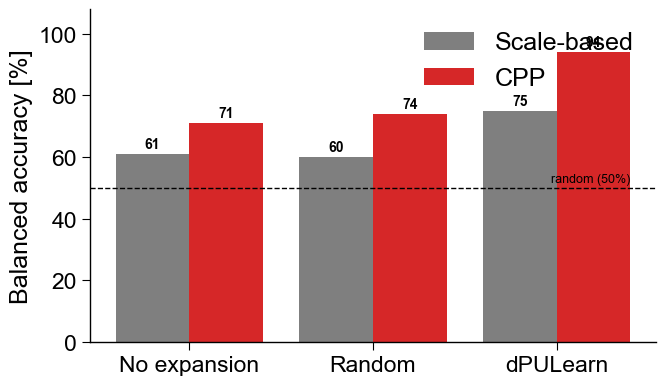

In [3]:
aa.plot_settings()
aa.plot_comparison(df_eval=df_eval, baseline=50, baseline_label="random (50%)",
                   colors={"Scale-based": "tab:gray", "CPP": "tab:red"},
                   group_order=["Scale-based", "CPP"],
                   ylabel="Balanced accuracy [%]", ylim=(0, 108))
plt.tight_layout()
plt.show()